# Análise de Viagens a Serviço do Governo Federal

## Camada Gold e perguntas de negócio

Este notebook apresenta análises sobre os gastos públicos com viagens a serviço, utilizando os dados tratados da camada Silver no MySQL.

O trabalho segue a Arquitetura Medallion:

- **Raw:** preservação fiel dos arquivos CSV;
- **Silver:** dados limpos, tipados e relacionados;
- **Gold:** agregações e métricas destinadas às perguntas de negócio.

### Tecnologias

- Python
- pandas
- matplotlib
- MySQL
- PyMySQL

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import banco


# Ajustes de exibição
pd.set_option(
    "display.float_format",
    lambda valor: f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

In [22]:
conexao = banco.conectar()

print("Conectado ao MySQL com sucesso.")

Conectado ao MySQL com sucesso.


In [23]:
def consultar(sql):
    """Executa uma consulta SQL e retorna o resultado como DataFrame."""
    return pd.read_sql(sql, conexao)

## Criação da camada Gold

Nesta etapa, os dados das tabelas Silver são agregados para facilitar as análises de pagamentos por órgão e tipo de pagamento.

A camada Gold será criada no MySQL em dois formatos:

- uma tabela materializada;
- uma view.


In [24]:
def executar(sql):
    """Executa um comando SQL que não retorna uma tabela."""
    cursor = conexao.cursor()

    try:
        cursor.execute(sql)
        conexao.commit()
    except Exception:
        conexao.rollback()
        raise
    finally:
        cursor.close()

In [25]:
executar("DROP VIEW IF EXISTS vw_gold_pagamentos_orgao")
executar("DROP TABLE IF EXISTS gold_pagamentos_orgao")

print("Estruturas Gold removidas.")

Estruturas Gold removidas.


In [26]:
SQL_CRIAR_GOLD = """
CREATE TABLE gold_pagamentos_orgao AS
SELECT
    v.nome_orgao_superior,
    p.nome_orgao_pagador,
    p.tipo_pagamento,
    COUNT(*) AS quantidade_pagamentos,
    COUNT(DISTINCT p.id_viagem) AS quantidade_viagens,
    SUM(p.valor) AS valor_total,
    AVG(p.valor) AS valor_medio
FROM silver_pagamento AS p
INNER JOIN silver_viagem AS v
    ON p.id_viagem = v.id_viagem
GROUP BY
    v.nome_orgao_superior,
    p.nome_orgao_pagador,
    p.tipo_pagamento
"""

executar(SQL_CRIAR_GOLD)

print("Tabela gold_pagamentos_orgao criada com sucesso.")

Tabela gold_pagamentos_orgao criada com sucesso.


In [27]:
SQL_CRIAR_VIEW_GOLD = """
CREATE VIEW vw_gold_pagamentos_orgao AS
SELECT
    v.nome_orgao_superior,
    p.nome_orgao_pagador,
    COUNT(*) AS quantidade_pagamentos,
    COUNT(DISTINCT p.id_viagem) AS quantidade_viagens,
    SUM(p.valor) AS valor_total,
    AVG(p.valor) AS valor_medio
FROM silver_pagamento AS p
INNER JOIN silver_viagem AS v
    ON p.id_viagem = v.id_viagem
GROUP BY
    v.nome_orgao_superior,
    p.nome_orgao_pagador
"""

executar(SQL_CRIAR_VIEW_GOLD)

print("View vw_gold_pagamentos_orgao criada com sucesso.")

View vw_gold_pagamentos_orgao criada com sucesso.


In [28]:
gold_pagamentos = consultar("""
SELECT *
FROM gold_pagamentos_orgao
ORDER BY valor_total DESC
LIMIT 10
""")

gold_pagamentos

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,nome_orgao_pagador,tipo_pagamento,quantidade_pagamentos,quantidade_viagens,valor_total,valor_medio
0,Ministério da Justiça e Segurança Pública,Fundo Nacional de Segurança Pública,DIÁRIAS,73474,24035,"265.735.341,14","3.616,73"
1,Ministério da Justiça e Segurança Pública,Sigiloso,DIÁRIAS,71495,49871,"162.972.420,10","2.279,49"
2,Ministério da Defesa,Comando da Aeronáutica,DIÁRIAS,31750,25729,"59.040.684,52","1.859,55"
3,Ministério da Justiça e Segurança Pública,Sigiloso,PASSAGEM,19461,10804,"34.632.600,76","1.779,59"
4,Ministério da Previdência Social,Instituto Nacional do Seguro Social,DIÁRIAS,12028,7192,"31.978.703,47","2.658,69"
5,Ministério do Meio Ambiente e Mudança do Clima,Instituto Brasileiro do Meio Ambiente e dos Re...,DIÁRIAS,11938,8747,"23.249.412,29","1.947,51"
6,Ministério da Defesa,Comando da Aeronáutica,PASSAGEM,14204,7732,"22.640.574,41","1.593,96"
7,Ministério da Defesa,Comando do Exército,DIÁRIAS,12334,11509,"20.182.652,62","1.636,34"
8,Ministério dos Povos Indígenas,Fundação Nacional dos Povos Indígenas,DIÁRIAS,6723,4070,"17.519.449,71","2.605,90"
9,Ministério das Relações Exteriores,Ministério das Relações Exteriores - Unidades ...,PASSAGEM,2510,1701,"16.629.733,46","6.625,39"


In [29]:
gold_view = consultar("""
SELECT *
FROM vw_gold_pagamentos_orgao
ORDER BY valor_total DESC
LIMIT 10
""")

gold_view

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,nome_orgao_pagador,quantidade_pagamentos,quantidade_viagens,valor_total,valor_medio
0,Ministério da Justiça e Segurança Pública,Fundo Nacional de Segurança Pública,79816,24116,"278.481.047,89","3.489,04"
1,Ministério da Justiça e Segurança Pública,Sigiloso,91546,50820,"197.808.706,47","2.160,76"
2,Ministério da Defesa,Comando da Aeronáutica,46193,32336,"81.769.144,77","1.770,16"
3,Ministério da Previdência Social,Instituto Nacional do Seguro Social,18324,7264,"37.427.601,45","2.042,55"
4,Ministério da Defesa,Comando do Exército,22837,13285,"36.872.643,95","1.614,60"
5,Ministério do Meio Ambiente e Mudança do Clima,Instituto Brasileiro do Meio Ambiente e dos Re...,16758,8809,"31.589.853,15","1.885,06"
6,Ministério das Relações Exteriores,Ministério das Relações Exteriores - Unidades ...,3705,1927,"25.605.376,38","6.911,03"
7,Ministério da Fazenda,Receita Federal do Brasil,18917,10063,"23.811.027,00","1.258,71"
8,Sem informação,Ministério da Agricultura e Pecuária - Unidade...,15298,10432,"21.543.010,18","1.408,22"
9,Ministério da Defesa,Ministério da Defesa - Unidades com vínculo di...,9324,5849,"20.984.081,74","2.250,55"


In [30]:
SQL_CONTAGEM_GOLD = """
SELECT
    'gold_pagamentos_orgao' AS estrutura,
    COUNT(*) AS quantidade
FROM gold_pagamentos_orgao

UNION ALL

SELECT
    'vw_gold_pagamentos_orgao',
    COUNT(*)
FROM vw_gold_pagamentos_orgao
"""

consultar(SQL_CONTAGEM_GOLD)

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,estrutura,quantidade
0,gold_pagamentos_orgao,730
1,vw_gold_pagamentos_orgao,249


## Pergunta 1

### Quais são os cinco órgãos superiores com maior gasto total em viagens?

In [31]:
SQL_ORGAOS = """
SELECT
    nome_orgao_superior,
    SUM(valor_total) AS gasto_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY gasto_total DESC
LIMIT 5
"""

orgaos = consultar(SQL_ORGAOS)
orgaos

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,gasto_total
0,Ministério da Justiça e Segurança Pública,"486.933.121,65"
1,Ministério da Defesa,"156.070.304,49"
2,Ministério da Educação,"111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,"49.697.710,16"
4,Ministério da Previdência Social,"40.417.309,06"


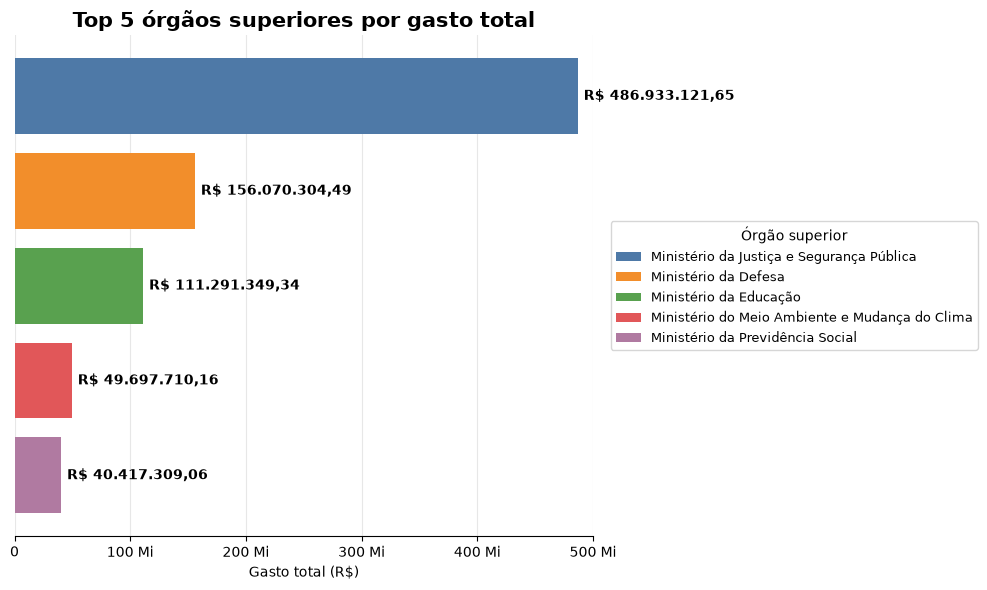

In [42]:
plt.figure(figsize=(14, 6))

cores = [
    "#4E79A7",
    "#F28E2B",
    "#59A14F",
    "#E15759",
    "#B07AA1"
]

barras = []

for posicao, (_, linha) in enumerate(orgaos.iterrows()):

    barra = plt.barh(
        posicao,
        linha["gasto_total"],
        color=cores[posicao],
        label=linha["nome_orgao_superior"]
    )

    barras.append(barra[0])

plt.title(
    "Top 5 órgãos superiores por gasto total",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gasto total (R$)")
plt.yticks([])

plt.xlim(0, 500_000_000)

plt.xticks(
    [
        0,
        100_000_000,
        200_000_000,
        300_000_000,
        400_000_000,
        500_000_000
    ],
    [
        "0",
        "100 Mi",
        "200 Mi",
        "300 Mi",
        "400 Mi",
        "500 Mi"
    ]
)

eixo = plt.gca()

# Mantém o grid atrás das barras
eixo.set_axisbelow(True)
eixo.grid(axis="x", alpha=0.3)

# Valor exato ao final de cada barra
for barra, valor in zip(barras, orgaos["gasto_total"]):

    valor_formatado = (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    plt.text(
        barra.get_width() + 5_000_000,
        barra.get_y() + barra.get_height() / 2,
        valor_formatado,
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Maior valor no topo
eixo.invert_yaxis()

# Legenda por cor fora do gráfico
plt.legend(
    title="Órgão superior",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Remove bordas desnecessárias
eixo.spines["top"].set_visible(False)
eixo.spines["right"].set_visible(False)
eixo.spines["left"].set_visible(False)

# Reserva espaço para a legenda
plt.tight_layout(rect=[0, 0, 0.72, 1])

plt.show()

**Interpretação**

Observa-se que poucos órgãos concentram a maior parte das despesas com viagens. Esse tipo de análise auxilia na identificação dos principais centros de custo e pode apoiar auditorias ou avaliações da distribuição dos recursos públicos.

## Pergunta 2

### Quais são os três destinos com maior custo médio por viagem?

In [43]:
SQL_DESTINOS = """
WITH viagens_por_destino AS (
    SELECT DISTINCT
        p.id_viagem,
        p.cidade_destino_ida,
        v.valor_total
    FROM silver_passagem AS p
    INNER JOIN silver_viagem AS v
        ON p.id_viagem = v.id_viagem
    WHERE p.cidade_destino_ida IS NOT NULL
      AND TRIM(p.cidade_destino_ida) <> ''
      AND v.valor_total IS NOT NULL
)

SELECT
    cidade_destino_ida,
    COUNT(*) AS quantidade_viagens,
    AVG(valor_total) AS custo_medio
FROM viagens_por_destino
GROUP BY cidade_destino_ida
ORDER BY custo_medio DESC
LIMIT 3
"""

destinos = consultar(SQL_DESTINOS)
destinos

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,cidade_destino_ida,quantidade_viagens,custo_medio
0,Mauá,1,"126.214,70"
1,Cambridge - Massachusetts,1,"86.678,04"
2,Livingstone,2,"86.452,66"


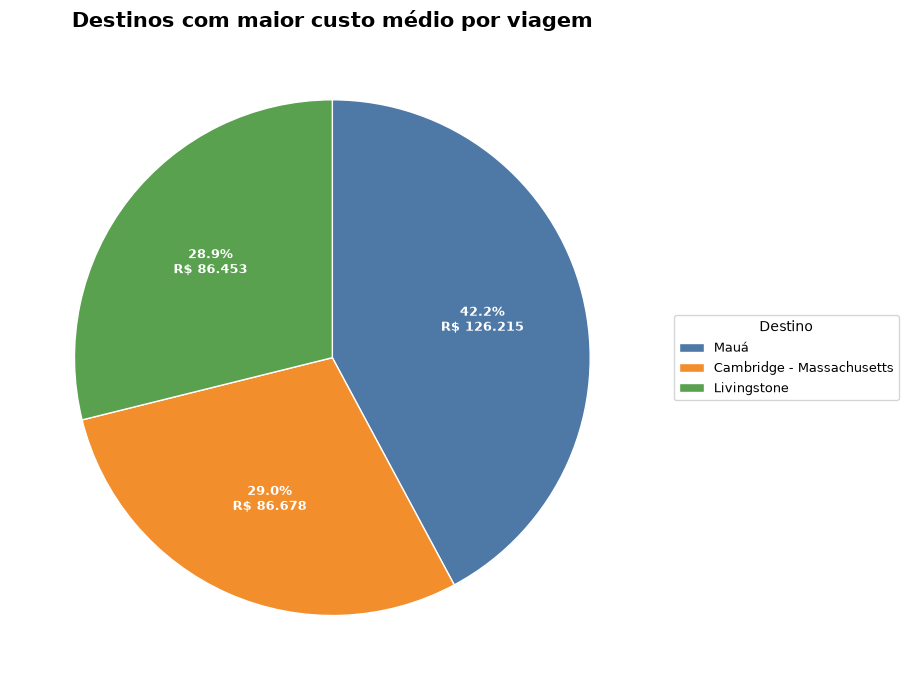

In [50]:
plt.figure(figsize=(12, 7))

cores = [
    "#4E79A7",
    "#F28E2B",
    "#59A14F",
]

# Função para mostrar % e valor em R$
def mostrar_valor(pct):
    valor = pct / 100 * destinos["custo_medio"].sum()

    valor = (
        f"R$ {valor:,.0f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    return f"{pct:.1f}%\n{valor}"

fatias, textos, autotextos = plt.pie(
    destinos["custo_medio"],
    colors=cores,
    autopct=mostrar_valor,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(
        fontsize=9,
        fontweight="bold",
        color="white"
    )
)

plt.title(
    "Destinos com maior custo médio por viagem",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    fatias,
    destinos["cidade_destino_ida"],
    title="Destino",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.75, 1])

plt.show()

**Interpretação**

Os destinos apresentados possuem o maior custo médio por viagem. Esse resultado pode refletir fatores como distância, disponibilidade de voos, diárias ou características específicas das missões realizadas nesses locais.

## Pergunta 3

### Qual foi a viagem de maior duração e qual foi seu custo total?

In [54]:
SQL_MAIOR_DURACAO = """
SELECT
    id_viagem,
    nome_orgao_superior,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1
"""

maior_duracao = consultar(SQL_MAIOR_DURACAO)
maior_duracao

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,nome_orgao_superior,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,383,"0,00"


In [55]:
SQL_MAIOR_DURACAO_COM_CUSTO = """
SELECT
    id_viagem,
    nome_orgao_superior,
    duracao_dias,
    valor_total
FROM silver_viagem
WHERE valor_total > 0
ORDER BY duracao_dias DESC
LIMIT 1
"""

maior_duracao_com_custo = consultar(SQL_MAIOR_DURACAO_COM_CUSTO)
maior_duracao_com_custo

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,nome_orgao_superior,duracao_dias,valor_total
0,0000000000020793594,Ministério da Justiça e Segurança Pública,378,"120.650,00"


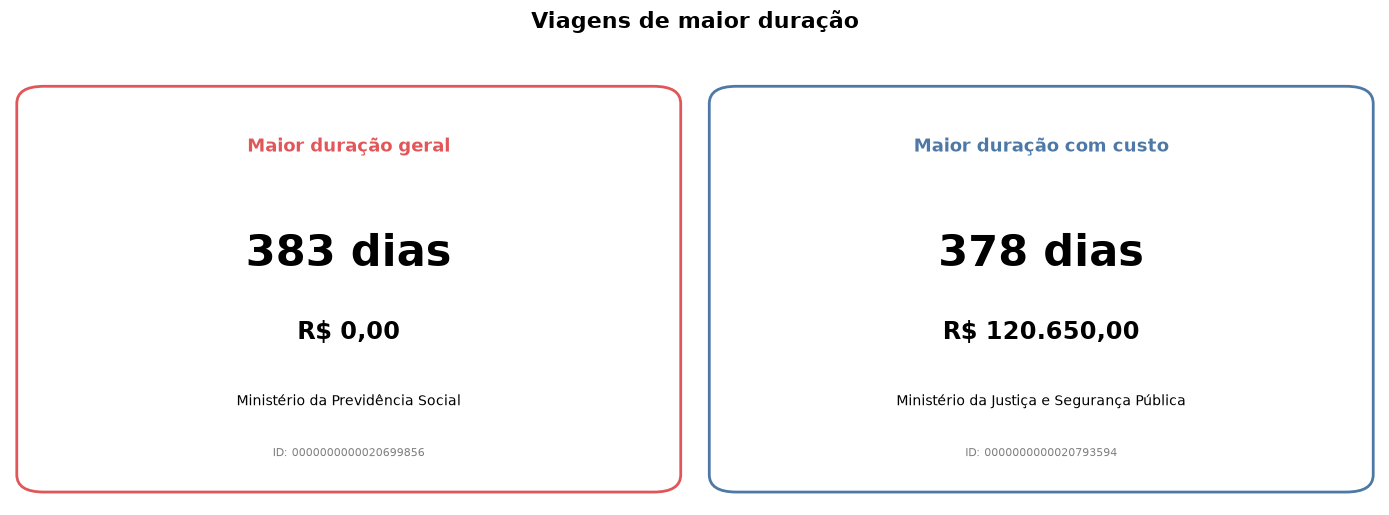

In [ ]:
from matplotlib.patches import FancyBboxPatch

# Extrair os registros das consultas
viagem_geral = maior_duracao.iloc[0]
viagem_com_custo = maior_duracao_com_custo.iloc[0]


def formatar_reais(valor):
    return (
        f"R$ {float(valor):,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )


def adicionar_card(
    eixo,
    titulo,
    viagem,
    cor,
):
    duracao = int(viagem["duracao_dias"])
    custo = formatar_reais(viagem["valor_total"])
    orgao = viagem["nome_orgao_superior"]
    id_viagem = viagem["id_viagem"]

    # Fundo arredondado do card
    card = FancyBboxPatch(
        (0.03, 0.05),
        0.94,
        0.90,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        transform=eixo.transAxes,
        facecolor="white",
        edgecolor=cor,
        linewidth=2
    )

    eixo.add_patch(card)

    # Título do indicador
    eixo.text(
        0.50,
        0.83,
        titulo,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=cor,
        transform=eixo.transAxes
    )

    # Big number: duração
    eixo.text(
        0.50,
        0.58,
        f"{duracao} dias",
        ha="center",
        va="center",
        fontsize=31,
        fontweight="bold",
        transform=eixo.transAxes
    )

    # Custo
    eixo.text(
        0.50,
        0.40,
        custo,
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        transform=eixo.transAxes
    )

    # Órgão
    eixo.text(
        0.50,
        0.24,
        orgao,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True,
        transform=eixo.transAxes
    )

    # ID da viagem
    eixo.text(
        0.50,
        0.12,
        f"ID: {id_viagem}",
        ha="center",
        va="center",
        fontsize=8,
        color="gray",
        transform=eixo.transAxes
    )

    eixo.set_xlim(0, 1)
    eixo.set_ylim(0, 1)
    eixo.axis("off")


# Criação da figura
fig, eixos = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

adicionar_card(
    eixos[0],
    "Maior duração geral",
    viagem_geral,
    "#E15759"
)

adicionar_card(
    eixos[1],
    "Maior duração com custo",
    viagem_com_custo,
    "#4E79A7"
)

fig.suptitle(
    "Viagens de maior duração",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

**Interpretação**

A consulta identifica a viagem com maior duração registrada, juntamente com seu custo total e o órgão responsável. Essa informação pode auxiliar na identificação de deslocamentos excepcionais ou de longa permanência.

## Pergunta 4

### Qual tipo de pagamento apresenta o maior valor médio?

In [57]:
SQL_TIPO_PAGAMENTO = """
SELECT
    tipo_pagamento,
    SUM(valor_total) AS valor_total,
    SUM(quantidade_pagamentos) AS quantidade_pagamentos,
    SUM(valor_total) / SUM(quantidade_pagamentos) AS valor_medio
FROM gold_pagamentos_orgao
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC
"""

tipos_pagamento = consultar(SQL_TIPO_PAGAMENTO)
tipos_pagamento

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,valor_total,quantidade_pagamentos,valor_medio
0,DIÁRIAS,"834.352.643,52","401.463,00","2.078,28"
1,PASSAGEM,"354.978.915,13","188.985,00","1.878,34"
2,Serviço correlato: seguro,"2.190.136,71","4.894,00","447,51"
3,RESTITUIÇÃO,"2.843.762,01","11.574,00","245,70"


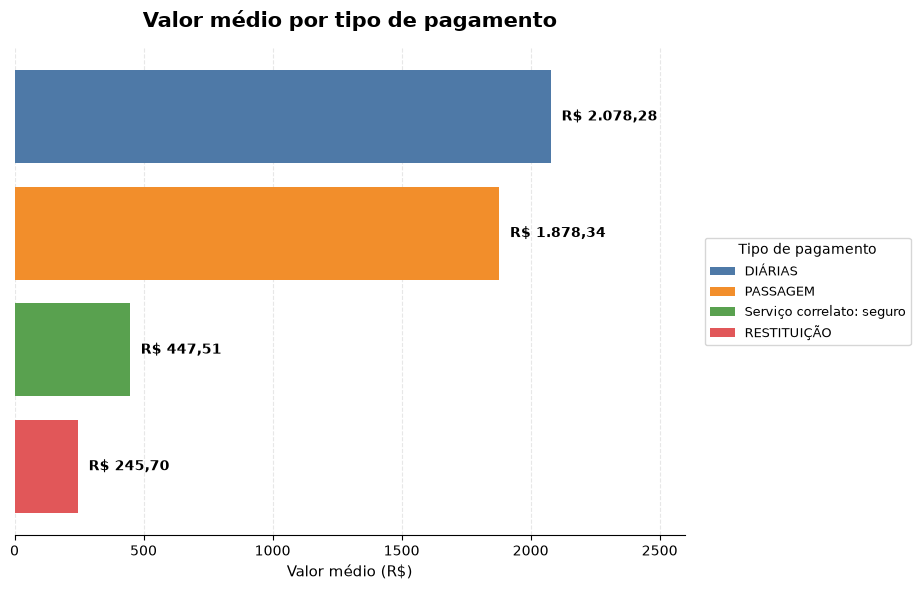

In [ ]:
from matplotlib.patches import Patch

# Ordenar do maior para o menor
tipos_ordenados = (
    tipos_pagamento
    .sort_values("valor_medio", ascending=False)
    .reset_index(drop=True)
)

cores = [
    "#4E79A7",
    "#F28E2B",
    "#59A14F",
    "#E15759",
    "#B07AA1",
    "#76B7B2",
    "#EDC948"
]

cores = cores[:len(tipos_ordenados)]

fig, ax = plt.subplots(figsize=(12, 6))

barras = ax.barh(
    tipos_ordenados.index,
    tipos_ordenados["valor_medio"],
    color=cores
)

# Coloca a maior barra no topo
ax.invert_yaxis()

ax.set_title(
    "Valor médio por tipo de pagamento",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Valor médio (R$)", fontsize=11)
ax.set_ylabel("")

# Remove os rótulos do eixo Y, pois os nomes estarão na legenda
ax.set_yticks([])

# Adiciona os valores ao final das barras
maior_valor = tipos_ordenados["valor_medio"].max()
espaco_texto = maior_valor * 0.02

for barra, valor in zip(
    barras,
    tipos_ordenados["valor_medio"]
):
    valor_formatado = (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    ax.text(
        valor + espaco_texto,
        barra.get_y() + barra.get_height() / 2,
        valor_formatado,
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

# Acrescenta espaço no eixo X para os valores não serem cortados
ax.set_xlim(
    0,
    maior_valor * 1.25
)

# Grade atrás das barras
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Criação manual da legenda
itens_legenda = [
    Patch(
        facecolor=cor,
        label=tipo
    )
    for cor, tipo in zip(
        cores,
        tipos_ordenados["tipo_pagamento"]
    )
]

ax.legend(
    handles=itens_legenda,
    title="Tipo de pagamento",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

**Interpretação**

A análise evidencia quais tipos de pagamento apresentam maior desembolso médio por ocorrência, permitindo identificar despesas potencialmente mais relevantes.

## Pergunta 5

### Qual o meio de transporte mais utilizado nos trechos?

In [62]:
SQL_TRANSPORTE = """
SELECT
    meio_transporte,
    COUNT(*) AS quantidade
FROM silver_trecho
WHERE meio_transporte IS NOT NULL
  AND TRIM(meio_transporte) <> ''
GROUP BY meio_transporte
ORDER BY quantidade DESC
"""

transportes = consultar(SQL_TRANSPORTE)
transportes

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,quantidade
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


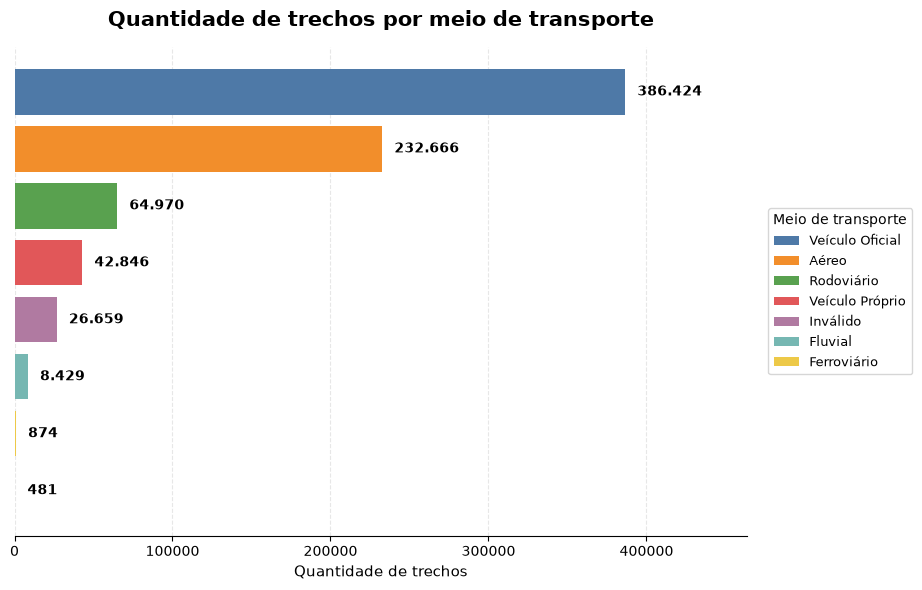

In [ ]:
# Ordenar do maior para o menor
transportes_ordenados = (
    transportes
    .sort_values("quantidade", ascending=False)
    .reset_index(drop=True)
)

cores = [
    "#4E79A7",
    "#F28E2B",
    "#59A14F",
    "#E15759",
    "#B07AA1",
    "#76B7B2",
    "#EDC948"
]

cores = cores[:len(transportes_ordenados)]

fig, ax = plt.subplots(figsize=(12, 6))

barras = ax.barh(
    transportes_ordenados.index,
    transportes_ordenados["quantidade"],
    color=cores
)

# Maior barra no topo
ax.invert_yaxis()

ax.set_title(
    "Quantidade de trechos por meio de transporte",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Quantidade de trechos", fontsize=11)
ax.set_ylabel("")

# Remove os nomes do eixo Y, pois estarão na legenda
ax.set_yticks([])

# Espaço proporcional para posicionar os valores
maior_quantidade = transportes_ordenados["quantidade"].max()
espaco_texto = maior_quantidade * 0.02

# Valores ao final das barras
for barra, valor in zip(
    barras,
    transportes_ordenados["quantidade"]
):
    ax.text(
        valor + espaco_texto,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor):,}".replace(",", "."),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

# Espaço para os valores não serem cortados
ax.set_xlim(0, maior_quantidade * 1.20)

# Grade atrás das barras
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Legenda separada com as cores dos meios de transporte
itens_legenda = [
    Patch(
        facecolor=cor,
        label=meio
    )
    for cor, meio in zip(
        cores,
        transportes_ordenados["meio_transporte"]
    )
]

ax.legend(
    handles=itens_legenda,
    title="Meio de transporte",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

**Interpretação**

O gráfico evidencia quais meios de transporte são mais utilizados nos deslocamentos oficiais, permitindo compreender o perfil logístico das viagens.

## Pergunta 6

### Qual UF aparece com maior frequência como destino?

In [65]:
SQL_DESTINO_UF = """
SELECT
    destino_uf,
    COUNT(*) AS quantidade
FROM silver_trecho
WHERE destino_uf IS NOT NULL
  AND TRIM(destino_uf) <> ''
GROUP BY destino_uf
ORDER BY quantidade DESC
"""

ufs = consultar(SQL_DESTINO_UF)
ufs

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,quantidade
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


In [ ]:
# Remove registros inválidos e ordena
ufs_ordenadas = (
    ufs[ufs["destino_uf"] != "Inválido"]
    .sort_values("quantidade", ascending=False)
    .reset_index(drop=True)
)

# Paleta com cores suficientes
cores = (
    list(plt.cm.tab20.colors) +
    list(plt.cm.Set3.colors)
)[:len(ufs_ordenadas)]

fig, ax = plt.subplots(figsize=(12, 10))

barras = ax.barh(
    ufs_ordenadas["destino_uf"],
    ufs_ordenadas["quantidade"],
    color=cores
)

# Maior valor no topo
ax.invert_yaxis()

ax.set_title(
    "Quantidade de trechos por UF de destino",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Quantidade de trechos",
    fontsize=11
)
ax.set_ylabel("")

# Valores nas barras
maior = ufs_ordenadas["quantidade"].max()
espaco = maior * 0.012

for barra, valor in zip(barras, ufs_ordenadas["quantidade"]):
    ax.text(
        valor + espaco,
        barra.get_y() + barra.get_height()/2,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xlim(0, maior * 1.15)

# Grade
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)
ax.set_axisbelow(True)

# Remove bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretação**

A distribuição das UFs de destino mostra quais estados concentram a maior parte dos deslocamentos realizados.

## Pergunta 7

### Qual órgão pagador concentrou o maior volume de pagamentos?

In [69]:
SQL_ORGAO_PAGADOR = """
SELECT
    nome_orgao_pagador,
    SUM(valor_total) AS valor_total
FROM gold_pagamentos_orgao
GROUP BY nome_orgao_pagador
ORDER BY valor_total DESC
LIMIT 10
"""

orgaos_pagadores = consultar(SQL_ORGAO_PAGADOR)
orgaos_pagadores

C:\Users\jpaul\AppData\Local\Temp\ipykernel_31132\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_pagador,valor_total
0,Fundo Nacional de Segurança Pública,"278.481.047,89"
1,Sigiloso,"200.484.801,68"
2,Comando da Aeronáutica,"81.769.144,77"
3,Instituto Nacional do Seguro Social,"37.427.601,45"
4,Comando do Exército,"36.872.643,95"
5,Ministério da Gestão e da Inovação em Serviços...,"35.541.760,71"
6,Instituto Brasileiro do Meio Ambiente e dos Re...,"31.589.853,15"
7,Ministério das Relações Exteriores - Unidades ...,"25.605.376,38"
8,Receita Federal do Brasil,"23.811.027,00"
9,Ministério da Agricultura e Pecuária - Unidade...,"22.899.880,25"


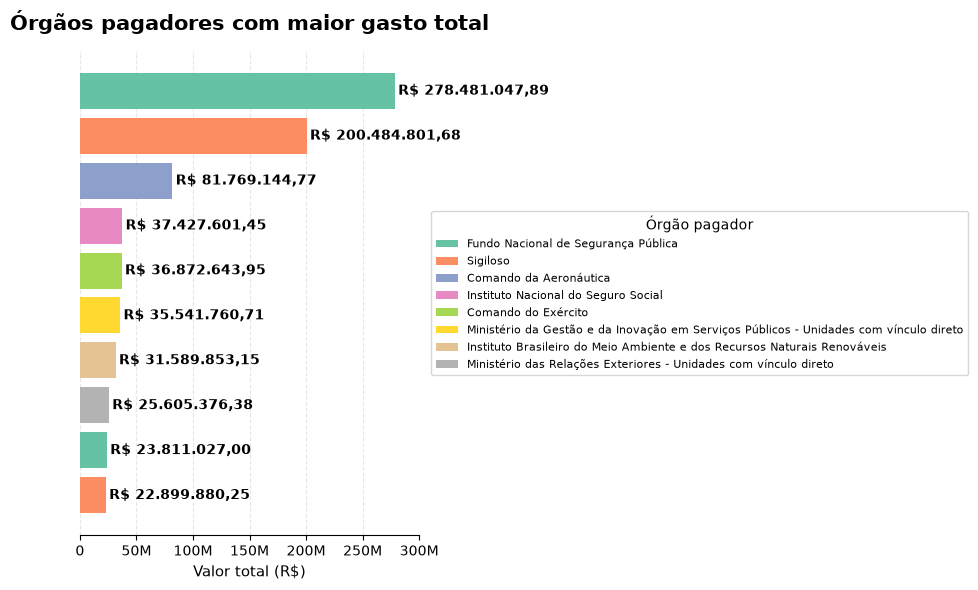

In [ ]:
# Ordena do maior para o menor
orgaos = (
    orgaos_pagadores
    .sort_values("valor_total", ascending=False)
    .reset_index(drop=True)
)

# Uma cor para cada órgão
cores = plt.cm.Set2.colors[:len(orgaos)]

fig, ax = plt.subplots(figsize=(13, 6))

barras = ax.barh(
    orgaos.index,
    orgaos["valor_total"],
    color=cores
)

# Maior valor no topo
ax.invert_yaxis()

ax.set_title(
    "Órgãos pagadores com maior gasto total",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Valor total (R$)",
    fontsize=11
)
ax.set_ylabel("")

# Remove os nomes do eixo Y
ax.set_yticks([])

# Valores nas barras
espaco = 3_000_000

for barra, valor in zip(barras, orgaos["valor_total"]):

    texto = (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    ax.text(
        valor + espaco,
        barra.get_y() + barra.get_height()/2,
        texto,
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Limites do eixo X
ax.set_xlim(0, 300_000_000)

# Marcações do eixo X
ax.set_xticks([
    0,
    50_000_000,
    100_000_000,
    150_000_000,
    200_000_000,
    250_000_000,
    300_000_000
])

ax.set_xticklabels([
    "0",
    "50M",
    "100M",
    "150M",
    "200M",
    "250M",
    "300M"
])

# Grade
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Legenda
legenda = [
    Patch(facecolor=cor, label=orgao)
    for cor, orgao in zip(
        cores,
        orgaos["nome_orgao_pagador"]
    )
]

ax.legend(
    handles=legenda,
    title="Órgão pagador",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    title_fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.72, 1])

plt.show()

**Interpretação**

O gráfico mostra os órgãos pagadores responsáveis pelos maiores desembolsos com viagens, permitindo identificar onde se concentram os maiores volumes financeiros.

In [74]:
conexao.close()

print("Conexão com o MySQL encerrada.")

Conexão com o MySQL encerrada.
